## Nome:Mayara Cristina
## Matrícula:574
---

# Atividade – Interpolação Polinomial

## Breve Explicação
A **interpolação polinomial** é um método numérico fundamental utilizado quando temos um conjunto de pontos conhecidos $(x_i, f(x_i))$ — normalmente obtidos por meio de resultados experimentais, tabelas ou medições de laboratório — e precisamos aproximar essa função desconhecida $f(x)$ por uma função polinomial $p_n(x)$ mais simples de manipular [cite: 1].

A condição básica da interpolação é que o polinômio $p_n(x)$ deve satisfazer a propriedade de passar exatamente por todos os pontos dados, ou seja:
$$p_n(x_i) = f(x_i), \quad para \ i = 0, 1, 2, ..., n$$

Conforme visto em aula, podemos determinar os coeficientes do polinômio interpolador resolvendo um **sistema de equações lineares** ou utilizando formulações específicas como o **Polinômio Interpolador de Lagrange**.

## Funções Auxiliares

In [1]:
# Importando bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Função de Apoio para Interpolação de Lagrange
def interpolacao_lagrange(x_pontos, y_pontos, x_val):
    """
    Calcula o valor do polinômio interpolador de Lagrange no ponto x_val.
    x_pontos: array com os valores de x conhecidos
    y_pontos: array com os valores de y conhecidos
    x_val: ponto onde se deseja estimar o valor
    """
    n = len(x_pontos)
    soma = 0.0
    for i in range(n):
        termo = y_pontos[i]
        for j in range(n):
            if j != i:
                termo = termo * (x_val - x_pontos[j]) / (x_pontos[i] - x_pontos[j])
        soma += termo
    return soma

---
# Parte Prática

## Contexto 1 – Desempenho de Robôs na FETIN
Durante os testes preparatórios para a **FETIN (Feira Tecnológica do Inatel)**, uma equipe de engenharia coletou dados do torque aplicado em um motor de tração de um robô autônomo em função da velocidade angular de teste.

Os dados medidos em laboratório foram organizados na tabela abaixo:

| Velocidade Angular (rad/s) | 1.0 | 2.0 | 3.0 |
|----------------------------|-----|-----|-----|
| Torque Medido (N.m)        | 2.5 | 6.0 | 11.5|

### Questão 1 – Sistema de Equações Lineares
1. Determine analiticamente ou via código o polinômio interpolador de 2º grau $p(x) = a_0 + a_1x + a_2x^2$ que passa exatamente pelos 3 pontos da tabela da FETIN, montando o sistema linear correspondente.

In [3]:
# Resolva a Questão 1 aqui (Monte o sistema linear ou utilize np.linalg.solve para encontrar a0, a1 e a2)
x_fetin = np.array([1.0, 2.0, 3.0])
y_fetin = np.array([2.5, 6.0, 11.5])

# Dica: Matriz de Vandermonde ou coeficientes via np.polyfit com grau 2 (que gera a interpolação exata para 3 pontos)
# Matriz do sistema:
# a0 + a1*x + a2*x² = y
A = np.column_stack((
    np.ones_like(x_fetin),
    x_fetin,
    x_fetin**2
))

# Resolve o sistema linear
a0, a1, a2 = np.linalg.solve(A, y_fetin)

print("Matriz do sistema linear:")
print(A)

print("\nVetor de resultados:")
print(y_fetin)

print(
    f"\nCoeficientes: a0 = {a0:.1f}, "
    f"a1 = {a1:.1f}, a2 = {a2:.1f}"
)

print(
    f"Polinômio interpolador: "
    f"p(x) = {a0:.1f} + {a1:.1f}x + {a2:.1f}x²"
)

Matriz do sistema linear:
[[1. 1. 1.]
 [1. 2. 4.]
 [1. 3. 9.]]

Vetor de resultados:
[ 2.5  6.  11.5]

Coeficientes: a0 = 1.0, a1 = 0.5, a2 = 1.0
Polinômio interpolador: p(x) = 1.0 + 0.5x + 1.0x²


2. Utilizando o polinômio encontrado, calcule uma estimativa para o torque do robô quando a velocidade angular for de $x = 2.5 \text{ rad/s}$.

In [4]:
# Calcule a estimativa para x = 2.5 aqui
x_estimado = 2.5

torque_estimado = (
    a0
    + a1 * x_estimado
    + a2 * x_estimado**2
)

print(
    f"Torque estimado para x = {x_estimado} rad/s: "
    f"{torque_estimado:.2f} N.m"
)

Torque estimado para x = 2.5 rad/s: 8.50 N.m


## Contexto 2 – Hackathon Inatel & Coneti
Em uma maratona de programação e inovação (**Hackathon do Inatel**), um grupo de alunos precisa modelar o consumo de banda de uma rede de sensores IoT instalada no campus inteligente. A tabela abaixo relaciona o tempo de operação (em horas) com o tráfego medido de dados (em GB):

| Tempo (h)       | 0   | 1   | 3   |
|-----------------|-----|-----|-----|
| Tráfego (GB)    | 1.2 | 2.5 | 8.1 |

### Questão 2 – Método de Lagrange
1. Implemente ou utilize a função de Lagrange fornecida para encontrar o valor aproximado do tráfego de dados no instante $t = 2.0 \text{ horas}$.

In [5]:
# Resolva a Questão 2 usando o método de Lagrange para t = 2.0
x_hack = np.array([0, 1, 3])
y_hack = np.array([1.2, 2.5, 8.1])

# Exemplo de chamada: valor_estimado = interpolacao_lagrange(x_hack, y_hack, 2.0)
t_estimado = 2.0

valor_estimado = interpolacao_lagrange(
    x_hack,
    y_hack,
    t_estimado
)

print(
    f"Tráfego estimado em t = {t_estimado} h: "
    f"{valor_estimado:.2f} GB"
)

Tráfego estimado em t = 2.0 h: 4.80 GB


2. Plote o gráfico comparando os pontos experimentais do Hackathon e a curva do polinômio interpolador gerado no intervalo de $0$ a $3$ horas.

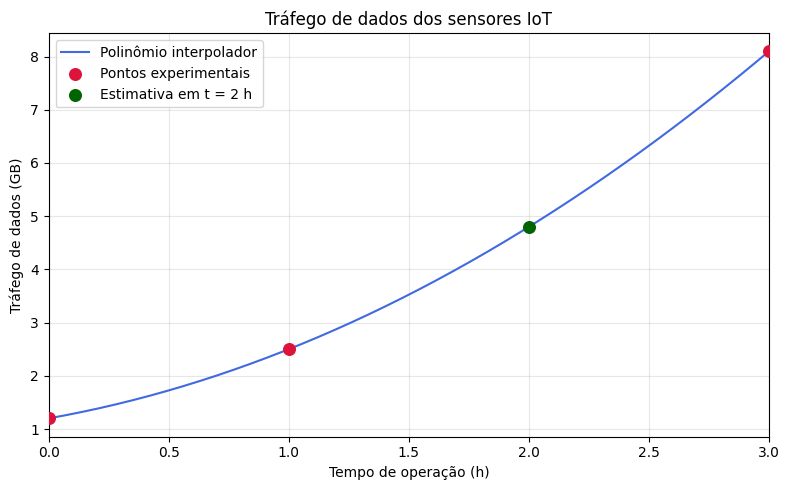

In [6]:
# Plote o gráfico aqui utilizando matplotlib
# Cria 300 valores entre 0 e 3
t_curva = np.linspace(0, 3, 300)

# Calcula o valor interpolado para cada ponto
trafego_curva = np.array([
    interpolacao_lagrange(x_hack, y_hack, t)
    for t in t_curva
])

plt.figure(figsize=(8, 5))

# Curva do polinômio
plt.plot(
    t_curva,
    trafego_curva,
    color="royalblue",
    label="Polinômio interpolador"
)

# Pontos da tabela
plt.scatter(
    x_hack,
    y_hack,
    color="crimson",
    s=70,
    zorder=3,
    label="Pontos experimentais"
)

# Estimativa em t = 2
plt.scatter(
    t_estimado,
    valor_estimado,
    color="darkgreen",
    s=70,
    zorder=3,
    label="Estimativa em t = 2 h"
)

plt.title("Tráfego de dados dos sensores IoT")
plt.xlabel("Tempo de operação (h)")
plt.ylabel("Tráfego de dados (GB)")
plt.xlim(0, 3)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---
# Parte Teórica

1. Explique com suas próprias palavras qual é a principal diferença conceitual entre **Interpolação Polinomial** e **Ajuste de Curvas por Mínimos Quadrados**.

**Resposta:**
Na interpolação polinomial, o polinômio deve passar exatamente por todos os pontos fornecidos. Já no ajuste de curvas por mínimos quadrados, a curva não precisa passar por todos os pontos, pois busca minimizar os erros entre os valores observados e os valores calculados. O método dos mínimos quadrados é mais indicado quando os dados possuem erros de medição ou ruídos.


2. O que ocorre com o grau do polinômio interpolador à medida que adicionamos mais pontos experimentais ao conjunto de dados? Cite uma possível desvantagem prática disso.

**Resposta:**
Para \(n+1\) pontos distintos, podemos construir um polinômio interpolador de grau máximo \(n\). Portanto, conforme adicionamos mais pontos, o grau do polinômio pode aumentar. Uma desvantagem é que polinômios de grau elevado podem apresentar grandes oscilações entre os pontos, principalmente nas extremidades do intervalo. Esse comportamento é conhecido como fenômeno de Runge.

3. Qual é a diferença entre **Interpolação** e **Extrapolação**, considerando a posição do ponto que se deseja estimar em relação ao intervalo dos dados conhecidos?

**Resposta:**
A interpolação é utilizada para estimar um valor que está dentro do intervalo dos dados conhecidos. Já a extrapolação estima um valor que está fora desse intervalo. A extrapolação geralmente é menos confiável, pois não existem dados conhecidos naquela região para confirmar se o comportamento da função continuará da mesma maneira.